In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import random

from DCmatch import Match

from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [3]:
folder = os.fsencode("seasons/bettingSeasons")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("seasons/bettingSeasons/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

1920-Copy1.csv
2021-Copy1.csv
2122-Copy1.csv
2223-Copy1.csv
2324-Copy1.csv
2425-Copy1.csv
2526-Copy1.csv


In [5]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HS", "AS", "HST", "AST", 
    "B365H", "B365D", "B365A", "MaxH", "MaxD", "MaxA", "AvgH", "AvgD", "AvgA"
]]

In [7]:
data.describe()

,FTHG,FTAG,HS,AS,HST,AST,B365H,B365D,B365A,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA
count,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000
mean,1.554622,1.320168,13.800000,11.664286,4.809664,4.111765,2.907231,4.260996,4.444929,3.116929,4.541450,5.021071,2.941971,4.292097,4.565773
std,1.326786,1.226037,5.692956,5.208182,2.600706,2.397655,2.090992,1.353086,3.780520,2.452117,1.582391,5.113378,2.144261,1.357441,4.123095
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.060000,2.800000,1.140000,1.090000,3.100000,1.170000,1.070000,2.970000,1.150000
25%,1.000000,0.000000,10.000000,8.000000,3.000000,2.000000,1.620000,3.500000,2.150000,1.700000,3.650000,2.250000,1.650000,3.490000,2.180000
50%,1.000000,1.000000,13.000000,11.000000,5.000000,4.000000,2.250000,3.800000,3.200000,2.380000,4.000000,3.300000,2.290000,3.820000,3.180000
75%,2.000000,2.000000,17.000000,15.000000,6.000000,5.000000,3.300000,4.500000,5.250000,3.480000,4.782500,5.600000,3.322500,4.550000,5.242500
max,9.000000,9.000000,36.000000,37.000000,16.000000,15.000000,19.000000,13.000000,29.000000,22.000000,17.000000,50.000000,18.090000,12.850000,37.570000


In [9]:
simpleData = data[["HomeTeam", "AwayTeam", "FTHG", "FTAG"]]
simpleData

,HomeTeam,AwayTeam,FTHG,FTAG
0,Liverpool,Norwich,4,1
1,West Ham,Man City,0,5
2,Bournemouth,Sheffield United,1,1
3,Burnley,Southampton,3,0
4,Crystal Palace,Everton,0,0
...,...,...,...,...
95,Tottenham,Chelsea,0,1
96,Liverpool,Aston Villa,2,0
97,West Ham,Newcastle,3,1
98,Man City,Bournemouth,3,1


In [11]:
uniqueTeams = data["HomeTeam"].unique()

In [13]:
teamsIndex = {}
for i in range(len(uniqueTeams)):
    teamsIndex[uniqueTeams[i]] = i
teamsIndex

{'Liverpool': 0,
 'West Ham': 1,
 'Bournemouth': 2,
 'Burnley': 3,
 'Crystal Palace': 4,
 'Watford': 5,
 'Tottenham': 6,
 'Leicester': 7,
 'Newcastle': 8,
 'Man United': 9,
 'Arsenal': 10,
 'Aston Villa': 11,
 'Brighton': 12,
 'Everton': 13,
 'Norwich': 14,
 'Southampton': 15,
 'Man City': 16,
 'Sheffield United': 17,
 'Chelsea': 18,
 'Wolves': 19,
 'Fulham': 20,
 'West Brom': 21,
 'Leeds': 22,
 'Brentford': 23,
 "Nott'm Forest": 24,
 'Luton': 25,
 'Ipswich': 26,
 'Sunderland': 27}

In [55]:
i = simpleData["HomeTeam"].tolist()
j = simpleData["AwayTeam"].tolist()
x = simpleData["FTHG"].tolist()
y = simpleData["FTAG"].tolist()

for n in range(len(i)):
    i[n] = teamsIndex.get(i[n])
    j[n] = teamsIndex.get(j[n])

In [35]:
phis = [phi(i) for i in range(3000)]

for k in range(len(i)):
    

likelihoods = [np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)]

[1.0,
 0.9935210793034477,
 0.9870841350202876,
 0.9806888951886662,
 0.9743350896087494,
 0.968022449831306,
 0.9617507091463667,
 0.9555196025719545,
 0.9493288668428895,
 0.9431782403996666,
 0.9370674633774034,
 0.9309962775948618,
 0.9249644265435393,
 0.9189716553768317,
 0.9130177108992658,
 0.9071023415558017,
 0.9012252974212048,
 0.895386330189486,
 0.8895851931634113,
 0.8838216412440785,
 0.8780954309205613,
 0.8724063202596221,
 0.866754068895489,
 0.861138438019701,
 0.8555591903710185,
 0.8500160902253981,
 0.8445089033860343,
 0.8390373971734638,
 0.8336013404157353,
 0.828200503438642,
 0.8228346580560184,
 0.8175035775600987,
 0.8122070367119391,
 0.8069448117319006,
 0.8017166802901953,
 0.796522421497492,
 0.7913618158955839,
 0.7862346454481167,
 0.7811406935313765,
 0.7760797449251368,
 0.7710515858035663,
 0.7660560037261941,
 0.7610927876289343,
 0.7561617278151685,
 0.751262615946886,
 0.7463952450358817,
 0.7415594094350105,
 0.7367549048294989,
 0.73198152822

In [15]:
from scipy.optimize import minimize
def phi(t):
    return np.exp(-0.0065*t)

def logLikelihood(parameters, data):
    numTeams = int((len(parameters) - 2) // 2)
    
    attackStrengths = np.array(parameters[0:numTeams])
    defenceStrengths = np.array(parameters[numTeams:numTeams*2])
    
    homeAdv = parameters[-2]
    rho = parameters[-1]
    t = data.index[-1]
    ll = 0

    for tk, row in data.iterrows():
        i = teamsIndex.get(row["HomeTeam"])
        j = teamsIndex.get(row["AwayTeam"])
        x = int(row["FTHG"])
        y = int(row["FTAG"])

        lamd = attackStrengths[i] * defenceStrengths[j] * homeAdv
        mu = attackStrengths[j] * defenceStrengths[i]

        ll += (np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)) * phi(t - tk)
    
    return -ll

In [17]:
from scipy.optimize import minimize
np.random.seed(1008)
def getNewEstimates(results: pd.DataFrame):
    rng = np.random.default_rng(123)
    init_att = rng.uniform(0.8, 1.3, size=len(uniqueTeams))
    init_def = rng.uniform(0.8, 1.3, size=len(uniqueTeams))
    init_home = 1.1
    init_rho = 0.0

    init = np.concatenate([init_att, init_def, [init_home, init_rho]])

    bounds = [(1e-6, None)] * (2*len(uniqueTeams)) + [(1e-6, None), (-0.99, 0.99)]

    result = minimize(
        logLikelihood,
        init,
        args=(results,),
        bounds=bounds,
        options={'maxiter': 10000, 'disp': True},
    )
    return result.x

In [42]:
estimatesAtTimeT = []
for i in range(7):
    estimatesAtTimeT.append(getNewEstimates(simpleData.head(n=380+i*380)))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           58     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.66462D+02    |proj g|=  3.79394D+01

At iterate    1    f=  2.55097D+02    |proj g|=  9.18392D+00

At iterate    2    f=  2.47235D+02    |proj g|=  7.40636D+00

At iterate    3    f=  2.30525D+02    |proj g|=  2.98158D+01

At iterate    4    f=  2.26757D+02    |proj g|=  1.54965D+00

At iterate    5    f=  2.25323D+02    |proj g|=  1.02208D+00

At iterate    6    f=  2.24346D+02    |proj g|=  5.99667D-01

At iterate    7    f=  2.24308D+02    |proj g|=  1.46149D+00

At iterate    8    f=  2.24278D+02    |proj g|=  2.70802D-01

At iterate    9    f=  2.24275D+02    |proj g|=  2.03931D-01

At iterate   10    f=  2.24272D+02    |proj g|=  1.20653D-01

At iterate   11    f=  2.24272D+02    |proj g|=  2.18478D-02

At iterate   12    f=  2.24272D+02    |proj g|=  3.19972D-02

At iterate   13    f=  2.2

In [54]:
parameterLists = [[estimatesAtTimeT[row][col] for row in range(7)] for col in range(58)]
parameterLists

[[1.7290309023808927,
  1.6430413280194451,
  1.734539985467697,
  1.7382800129354061,
  1.7541570120240686,
  1.802288621661045,
  1.7946699282577552],
 [1.1205880993570592,
  1.3151635782901074,
  1.2909906396489867,
  1.2358432660338041,
  1.2439712748435434,
  1.2331542593254203,
  1.2256950491150458],
 [0.9363102814498356,
  0.9614278036777076,
  0.9715916583214598,
  0.8850890290946027,
  0.9910485472069087,
  1.0646324295907654,
  1.0708293803828373],
 [0.8693551547186015,
  0.8804594790124782,
  0.8355054987182786,
  0.8238340157492581,
  0.8498200034337765,
  0.864811559950095,
  0.8678239413885807],
 [0.5839433320965748,
  0.755060258090943,
  0.8541444440376605,
  0.8774610617970912,
  1.0284890646877605,
  1.095345043830043,
  1.0952241165097876],
 [0.8645651073888319,
  0.8934274833469324,
  0.7754541393749054,
  0.7675598287057017,
  0.765018953090935,
  0.7771198372075135,
  0.7749401303643628],
 [1.264611021834452,
  1.4600826392064008,
  1.5797780301458633,
  1.5695850

In [19]:
parameterLists = [[1.7290309023808927,
  1.6430413280194451,
  1.734539985467697,
  1.7382800129354061,
  1.7541570120240686,
  1.802288621661045,
  1.7946699282577552],
 [1.1205880993570592,
  1.3151635782901074,
  1.2909906396489867,
  1.2358432660338041,
  1.2439712748435434,
  1.2331542593254203,
  1.2256950491150458],
 [0.9363102814498356,
  0.9614278036777076,
  0.9715916583214598,
  0.8850890290946027,
  0.9910485472069087,
  1.0646324295907654,
  1.0708293803828373],
 [0.8693551547186015,
  0.8804594790124782,
  0.8355054987182786,
  0.8238340157492581,
  0.8498200034337765,
  0.864811559950095,
  0.8678239413885807],
 [0.5839433320965748,
  0.755060258090943,
  0.8541444440376605,
  0.8774610617970912,
  1.0284890646877605,
  1.095345043830043,
  1.0952241165097876],
 [0.8645651073888319,
  0.8934274833469324,
  0.7754541393749054,
  0.7675598287057017,
  0.765018953090935,
  0.7771198372075135,
  0.7749401303643628],
 [1.264611021834452,
  1.4600826392064008,
  1.5797780301458633,
  1.5695850127184168,
  1.5458265923990522,
  1.5105336635656996,
  1.5045384602552225],
 [1.1537070559209317,
  1.3545890359179764,
  1.386959868577762,
  1.2994915231281312,
  1.2872035967272892,
  1.1820134724027525,
  1.178738120591174],
 [0.8527543677689031,
  1.0549701747628557,
  1.0632041816079514,
  1.1890385745617738,
  1.3415769515345835,
  1.3992648163468278,
  1.3884388674718184],
 [1.5209882527684428,
  1.5942880521203902,
  1.4509048838655128,
  1.3862181857767086,
  1.3785397754742958,
  1.3352985969784597,
  1.3369702706274147],
 [1.2205958653556657,
  1.3315955559543733,
  1.379056839700602,
  1.4950615132259102,
  1.592737063821262,
  1.5948458114216957,
  1.5887932735345522],
 [0.7518875260075627,
  0.9673838656704785,
  1.0359498143766368,
  1.0685638586942354,
  1.1588761937878396,
  1.2021160891685427,
  1.195328709581023],
 [0.7600403429021151,
  0.8333599083997587,
  0.9241330789514992,
  1.1022316095643538,
  1.0533966054668629,
  1.1743122786202536,
  1.1763373301271771],
 [0.8756538765948295,
  0.8540276557823177,
  0.8945165472496168,
  0.8918573918051779,
  0.8746299120456834,
  0.9158344297548869,
  0.9129338533998974],
 [0.3419238550734528,
  0.35825570165338283,
  0.44571862318810324,
  0.43949381258725506,
  0.4332324300952745,
  0.43876591821294825,
  0.4373610652876787],
 [1.190813566272716,
  1.1169791405162608,
  1.0570549524724069,
  1.0331840440683802,
  1.022482059491633,
  0.9512423784933086,
  0.9485877243454064],
 [2.1194100540480356,
  2.1564743218140485,
  2.2382043815861783,
  2.1357672686691287,
  2.1408825969603624,
  2.084389365878718,
  2.0739046951768736],
 [0.7782592668471525,
  0.6198895520283326,
  0.6241628981889854,
  0.6173224040874207,
  0.6768964678823173,
  0.6909426615907416,
  0.6889443924754161],
 [1.490813822610952,
  1.3684498341041582,
  1.4254550150683454,
  1.2641731078469758,
  1.4021306894693573,
  1.3953382098583311,
  1.3939414109007169],
 [0.9911873955455784,
  0.900671216405272,
  0.9034859935893033,
  0.8598179532202392,
  0.8747912648610462,
  0.9444734348697885,
  0.9381328703166197],
 [0.9157778124085338,
  0.5341384555751079,
  0.532390683748835,
  0.8846866294757073,
  1.0060144700818112,
  1.0693641373565148,
  1.0669863231555912],
 [0.8829519966203723,
  0.9382417589700056,
  0.9280458249889755,
  0.9027241093676615,
  0.892293981390718,
  0.904696380382114,
  0.9021145933758858],
 [1.048894484248897,
  1.4269688496660353,
  1.1933406272289844,
  1.141508791965671,
  1.1321729742629132,
  1.1481909934836738,
  1.1347333716956105],
 [1.0913623203076601,
  1.0913623203076601,
  1.155088097671463,
  1.1918444857468944,
  1.2071034666731184,
  1.2911403382315838,
  1.2890530413433225],
 [0.8921689937142399,
  0.8921689937142399,
  0.8921689937142399,
  1.071278845315619,
  1.1193078583736558,
  1.1889882270302743,
  1.1710764578920607],
 [0.8074474583801161,
  0.8074474583801161,
  0.8074474583801161,
  0.8074474583801161,
  1.2100524404230362,
  1.2517165597270814,
  1.2479437305783254],
 [1.0355666144452305,
  1.0355666144452305,
  1.0355666144452305,
  1.0355666144452305,
  1.0355666144452305,
  0.807776861284609,
  0.8045584211740885],
 [1.1641216640916308,
  1.1641216640916308,
  1.1641216640916308,
  1.1641216640916308,
  1.1641216640916308,
  1.1641216640916308,
  1.0604008727166416],
 [0.8768696484779716,
  0.8246403626781359,
  0.7133420155029839,
  0.7742283345125006,
  0.7900209837725127,
  0.8149112730715001,
  0.820265661740924],
 [1.2175618767229341,
  1.133075418881376,
  1.1233826413693653,
  1.124190387720668,
  1.1929050037952769,
  1.1697901184616915,
  1.1761542975285453],
 [1.4096033919724407,
  1.4579005540962606,
  1.4320922343655533,
  1.3595689361768937,
  1.2966518148195898,
  1.176158244584048,
  1.1739944858364153],
 [0.9021744690485562,
  1.1118041882728489,
  1.0971332867432022,
  1.0775799522475467,
  1.147701423252973,
  1.1394027214228035,
  1.145182477569628],
 [1.1637037435589104,
  1.3042827483495878,
  1.1408605885926648,
  1.0846495064514916,
  1.044250851554971,
  1.0292729339993685,
  1.0269749243930304],
 [1.4133790373930146,
  1.4351507473975327,
  1.5267196677477712,
  1.5174356518829104,
  1.465432058477746,
  1.4689084188366635,
  1.4711786324685168],
 [0.9203837975911009,
  1.0146247882278785,
  0.8954745498662664,
  1.0227049988886778,
  1.0491820214891785,
  1.1171891112403078,
  1.1134457412026155],
 [1.0600533253249291,
  1.1523431372027948,
  1.1303642460535543,
  1.173454027993974,
  1.1316171079164534,
  1.1877323955414303,
  1.1904128400948022],
 [1.2838139504486192,
  1.2984571833901681,
  1.202137283566693,
  1.0722605754356034,
  1.097103423082124,
  1.0549183895062486,
  1.0546968715790486],
 [0.6625180378096839,
  0.7891658528824745,
  0.9428205249259128,
  0.8796618550489537,
  0.9284731206364051,
  0.9427517658503244,
  0.947053297668676],
 [0.9404610919397886,
  0.882950723126284,
  0.9337002561574861,
  0.9366838008681257,
  0.825125525868575,
  0.7972521793199014,
  0.7903496908873185],
 [1.2622839978833162,
  1.163195179098123,
  1.1220651511819257,
  1.0191633736457013,
  1.0640703184407647,
  1.0171808779421418,
  1.014376507555405],
 [1.1591948221543626,
  1.011902404051311,
  0.9594768179363261,
  1.003168961566654,
  1.0136974576761377,
  1.0365508205351999,
  1.039967505074255],
 [1.1655114271410325,
  1.0780836523205968,
  1.1661756180725389,
  1.1658765105191402,
  1.0872685888013685,
  1.0181068436311067,
  1.0192086185011464],
 [1.550762201603159,
  1.6201992198568056,
  1.706587274326539,
  1.69475769132277,
  1.6480429347248047,
  1.6505270974356994,
  1.6536662826622757],
 [1.0546489711240798,
  1.3184489778427237,
  1.4042616082918509,
  1.4470732251320508,
  1.3987074755956426,
  1.424470645034571,
  1.4277314818109266],
 [0.6104610247690127,
  0.744017190476488,
  0.7175332468396761,
  0.6742662395260203,
  0.6343011251006158,
  0.6423803023161819,
  0.6429428931275353],
 [0.9056316771446979,
  1.1057996290187457,
  1.0919732375075204,
  1.0770760280866944,
  1.408223210261501,
  1.3996864835569502,
  1.4024090682208905],
 [1.2189879340920824,
  0.9758363805802511,
  0.9206580091871317,
  0.9425593877873563,
  0.9874093778498415,
  0.9367293998834393,
  0.9369397249302628],
 [0.7515776936139068,
  0.9583682186936,
  1.0162121248643607,
  1.0674917520837242,
  1.0946232210537101,
  1.0918106696704535,
  1.1018638633555466],
 [1.0483509208976702,
  1.1043008125524312,
  1.1041152673385717,
  1.0634347008251324,
  1.0779048286611772,
  1.0766910968417849,
  1.078182611212041],
 [1.0341562672132882,
  1.507068295305278,
  1.5040690566366097,
  1.4741880645336702,
  1.4248264993854003,
  1.4229741724927836,
  1.4278540887189757],
 [0.8638451614462389,
  0.8939051382727434,
  1.2420122476873667,
  1.3954760395750878,
  1.3520625862389877,
  1.347837336366457,
  1.351018980077143],
 [0.928781252454762,
  0.928781252454762,
  1.1383473916242102,
  0.915657925432615,
  1.026203209857064,
  1.0210982981392354,
  1.0248380635090624],
 [0.8015905546466559,
  0.8015905546466559,
  0.8015905546466559,
  1.297028086460426,
  1.2971903445567807,
  1.16575785546099,
  1.1755077098666447],
 [0.9905338739079096,
  0.9905338739079096,
  0.9905338739079096,
  0.9905338739079096,
  1.8488955919119552,
  1.8174428629279102,
  1.8221897808828489],
 [1.0879365420184834,
  1.0879365420184834,
  1.0879365420184834,
  1.0879365420184834,
  1.0879365420184834,
  1.6658056835408073,
  1.6695709337128373],
 [1.0136493856414752,
  1.0136493856414752,
  1.0136493856414752,
  1.0136493856414752,
  1.0136493856414752,
  1.0136493856414752,
  0.6455559485105832],
 [1.3186756535525195,
  1.15877453892049,
  1.152978532920387,
  1.1889613435327848,
  1.1942080491823461,
  1.175000117312061,
  1.177728435280809],
 [-0.09385685311580447,
  -0.03794598891824561,
  -0.03045285213442844,
  0.006647130179468142,
  -4.7735922718445795e-05,
  0.005517834647169369,
  0.005128801843636628]]

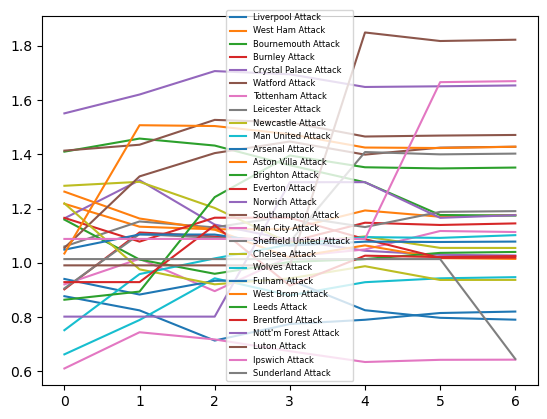

In [29]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

fig, ax = plt.subplots()
for i in range(28):
    ax.plot(parameterLists[28+i], label=f"{teamsLookup.get(i)} Attack")

ax.legend(prop={'size': 6})

In [20]:
match = Match(1.5939, 0.7916, 1.5544, 1.0414, 1.1803, -0.0026, 7)

In [21]:
for prob in match.getOutcomeProbs():
    print(f"{1/prob}", end=" ")

1.8471827980927995 4.535371019906162 4.199105900215088 

In [26]:
simpleData.describe()

,FTHG,FTAG
count,2270.000000,2270.000000
mean,1.558590,1.324229
std,1.331337,1.234756
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,9.000000,9.000000


In [39]:
simpleData.head(n=10000)

,HomeTeam,AwayTeam,FTHG,FTAG
0,Liverpool,Norwich,4,1
1,West Ham,Man City,0,5
2,Bournemouth,Sheffield United,1,1
3,Burnley,Southampton,3,0
4,Crystal Palace,Everton,0,0
...,...,...,...,...
95,Tottenham,Chelsea,0,1
96,Liverpool,Aston Villa,2,0
97,West Ham,Newcastle,3,1
98,Man City,Bournemouth,3,1
